# Estudo de caso 5.3 - O filtro de Kalman em 3D

**Configuração do *notebook***

In [1]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

## Geração de dados

Precisamos gerar sinteticamente medições ruidosas da posição do objeto (bola) em 3D. Em Python, podemos fazer isso da seguinte maneira:

In [2]:
# intervalo de tempo
dt = 0.01
# número total de medições
m = 200
# posição no início
px= 0.0
py= 0.0
pz= 1.0
# velocidades no início
vx = 5.0
vy = 3.0
vz = 0.0
# Coeficiente de resistência de arrasto
c = 0.1
# Amortecimento
d = 0.9
# Arrays para armazenar medições de posição
Xr=[]
Yr=[]
Zr=[]

# Gerando dados
for i in range(0, m):
  # atualizar aceleração (desaceleração), velocidade e posição na direção x
  accx = -c*vx**2
  vx += accx*dt
  px += vx*dt
  # atualizar aceleração (desaceleração), velocidade e posição na direção y
  accy = -c*vy**2
  vy += accy*dt
  py += vy*dt
  # atualizar aceleração (desaceleração), velocidade e posição na direção z
  accz = -9.806 + c*vz**2
  vz += accz*dt
  pz += vz*dt
  # se o objeto estiver a ponto de tocar a base...
  # alterar direção com amortecimento
  if pz<0.01:
    vz= -vz*d
    pz+=0.02
  # adicionar às arrays de armazenamento da posição
  Xr.append(px)
  Yr.append(py)
  Zr.append(pz)

# Adicionar ruído aleatório às medições
# Desvio típico do ruído
sp= 0.1
Xm = Xr + sp * (np.random.randn(m))
Ym = Yr + sp * (np.random.randn(m))
Zm = Zr + sp * (np.random.randn(m))

# Empilhar as medições para facilitar o manuseio posteriormente
measurements = np.vstack((Xm,Ym,Zm))

Visualização dos dados gerados:

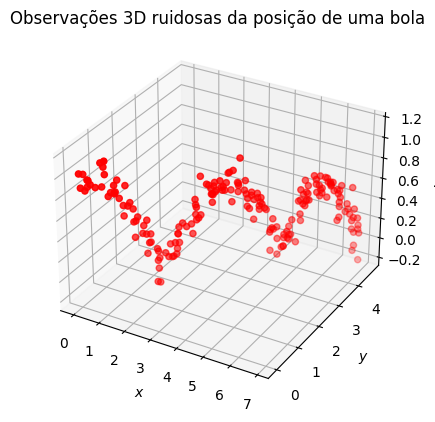

In [3]:
fig = plt.figure()
plot3D = fig.add_subplot(111, projection='3d')
plot3D.scatter(Xm, Ym, Zm, c='red')
plot3D.set_xlabel('$x$')
plot3D.set_ylabel('$y$')
plot3D.set_zlabel('$z$')
plt.title('Observações 3D ruidosas da posição de uma bola')

plt.show()

## Inicialização de variáveis

Podemos inicializar as variáveis ​​e matrizes que são especificadas no modelo da seguinte maneira:

In [4]:
# Matriz de identidade
I = np.eye(9)
# Matriz de estado
x = np.matrix([0.0, 0.0, 1.0, 5.0, 3.0, 0.0, 0.0, 0.0, -9.81]).T
# Matriz P
P = 100.0*np.eye(9)
# Matriz A
A = np.matrix([[1.0, 0.0, 0.0, dt, 0.0, 0.0, 1/2.0*dt**2, 0.0, 0.0],
               [0.0, 1.0, 0.0, 0.0, dt, 0.0, 0.0, 1/2.0*dt**2, 0.0],
               [0.0, 0.0, 1.0, 0.0, 0.0, dt, 0.0, 0.0, 1/2.0*dt**2],
               [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, dt, 0.0, 0.0],
               [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, dt, 0.0],
               [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, dt],
               [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
               [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
               [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]])
# Matriz H
H = np.matrix([[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
               [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
               [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])
# Matriz R
r = 1.0
R = np.matrix([[r, 0.0, 0.0],
               [0.0, r, 0.0],
               [0.0, 0.0, r]])

# Matrizes Q e G
s = 8.8
G = np.matrix([[1/2.0*dt**2],
               [1/2.0*dt**2],
               [1/2.0*dt**2],
               [dt],
               [dt],
               [dt],
               [1.0],
               [1.0],
               [1.0]])

Q = G*G.T*s**2

## Algoritmo do Filtro de Kalman

In [5]:
# As seguintes variáveis irão salvar os resultados em cada iteração
xt = []
yt = []
zt = []
dxt= []
dyt= []
dzt= []
ddxt=[]
ddyt=[]
ddzt=[]
Zx = []
Zy = []
Zz = []
Px = []
Py = []
Pz = []
Pdx= []
Pdy= []
Pdz= []
Pddx=[]
Pddy=[]
Pddz=[]
Kx = []
Ky = []
Kz = []
Kdx= []
Kdy= []
Kdz= []
Kddx=[]
Kddy=[]
Kddz=[]

**Algoritmo do Filtro de Kalman**

In [6]:
onFloor = False
for i in range(0, m):
  # Mudança de direção do modelo ao tocar a base
  if x[2]<0.02 and not onFloor:
    x[5] = -x[5]
    onFloor=True

  # Previsão
  # Previsão de estado
  x = A*x #+ B*u (B=0 y u=0)
  # Projetar a covariância do erro para frente
  P = A*P*A.T + Q

  # Atualizar
  # Ganho do Kalman
  S = H*P*H.T + R
  K = (P*H.T) * np.linalg.pinv(S)
  # Atualizar a estimativa via z
  Z = measurements[:,i].reshape(H.shape[0],1)
  y = Z - (H*x)
  x = x + (K*y)
  # Covariância do erro
  P = (I - (K*H))*P

  # Salvar os resultados
  xt.append(float(x[0]))
  yt.append(float(x[1]))
  zt.append(float(x[2]))
  dxt.append(float(x[3]))
  dyt.append(float(x[4]))
  dzt.append(float(x[5]))
  ddxt.append(float(x[6]))
  ddyt.append(float(x[7]))
  ddzt.append(float(x[8]))
  Zx.append(float(Z[0]))
  Zy.append(float(Z[1]))
  Zz.append(float(Z[2]))
  Px.append(float(P[0,0]))
  Py.append(float(P[1,1]))
  Pz.append(float(P[2,2]))
  Pdx.append(float(P[3,3]))
  Pdy.append(float(P[4,4]))
  Pdz.append(float(P[5,5]))
  Pddx.append(float(P[6,6]))
  Pddy.append(float(P[7,7]))
  Pddz.append(float(P[8,8]))
  Kx.append(float(K[0,0]))
  Ky.append(float(K[1,0]))
  Kz.append(float(K[2,0]))
  Kdx.append(float(K[3,0]))
  Kdy.append(float(K[4,0]))
  Kdz.append(float(K[5,0]))
  Kddx.append(float(K[6,0]))
  Kddy.append(float(K[7,0]))
  Kddz.append(float(K[8,0]))


## Resultados

Estimativas de estado:

Text(0.5, 0, 'Step')

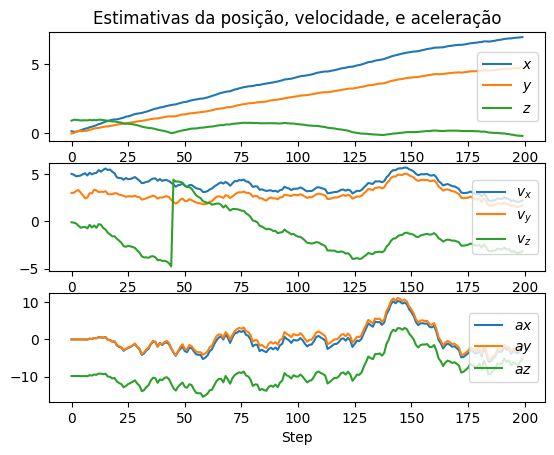

In [7]:
#Estimativas de estado
plt.subplot(311)
plt.title('Estimativas da posição, velocidade, e aceleração')
plt.plot(range(len(measurements[0])),xt, label='$x$')
plt.plot(range(len(measurements[0])),yt, label='$y$')
plt.plot(range(len(measurements[0])),zt, label='$z$')
plt.legend(loc='right' )

plt.subplot(312)
plt.plot(range(len(measurements[0])),dxt, label='$v_x$')
plt.plot(range(len(measurements[0])),dyt, label='$v_y$')
plt.plot(range(len(measurements[0])),dzt, label='$v_z$')
plt.legend(loc='right')

plt.subplot(313)
plt.plot(range(len(measurements[0])),ddxt, label='$ax$')
plt.plot(range(len(measurements[0])),ddyt, label='$ay$')
plt.plot(range(len(measurements[0])),ddzt, label='$az$')
plt.legend(loc='right')
plt.xlabel('Step')

Posição em 2D (z,y):

Text(0, 0.5, '$z$')

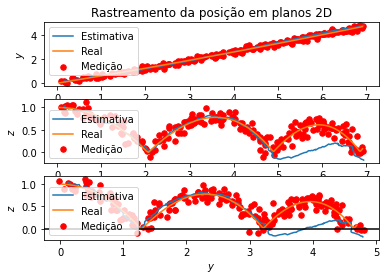

In [ ]:
plt.subplot(311)
plt.plot(xt,yt, label='Estimativa')
plt.scatter(Xm,Ym, label='Medição', c='red', s=30)
plt.plot(Xr, Yr, label='Real')
plt.title('Rastreamento da posição em planos 2D')
plt.legend(loc='best')
plt.xlabel('$x$')
plt.ylabel('$y$')

plt.subplot(312)
plt.plot(xt,zt, label='Estimativa')
plt.scatter(Xm,Zm, label='Medição', c='red', s=30)
plt.plot(Xr, Zr, label='Real')
plt.legend(loc='best')
plt.xlabel('$x$')
plt.ylabel('$z$')

plt.subplot(313)
plt.plot(yt,zt, label='Estimativa')
plt.scatter(Ym,Zm, label='Medição', c='red', s=30)
plt.plot(Yr, Zr, label='Real')
plt.legend(loc='best')
plt.axhline(0, color='k')
plt.xlabel('$y$')
plt.ylabel('$z$')

Posição em 3D (X,Y,Z):

In [ ]:
fig = plt.figure()
plot3D = fig.add_subplot(111, projection='3d')
plot3D.plot(xt,yt,zt, label='Estimativa')
plot3D.scatter(Xm,Ym,Zm, label='Medição', c='red')
plot3D.plot(Xr, Yr, Zr, label='Real')
plot3D.set_xlabel('$x$')
plot3D.set_ylabel('$y$')
plot3D.set_zlabel('$z$')
plot3D.legend()
plt.title('Rastreamento da posição em 3D')

plt.show()

---

Referências:

* https://balzer82.github.io/Kalman/